# Bluesky: Synchronous Run Saved to Tiled Server

## Imports

### Global Imports

In [1]:
import numpy as np

from bluesky import RunEngine
from bluesky.callbacks import LiveTable
from bluesky.plans import count, list_scan
import bluesky.plan_stubs as bps

from bluesky.callbacks.tiled_writer import TiledWriter
from tiled.server import SimpleTiledServer
from tiled.client import from_uri

from ophyd_async.core import init_devices

import matplotlib.pyplot as plt

### Local-File Imports

In [2]:
from sidekick_model3_CA_devices import PulseGenerator, LilLaser, Diode
from sidekick_model3_PVA_devices_v3 import DiodePVA

## Initialize our Sidekick Model 3 Devices

### Simple Device Interfaces (Channel Access, ophyd)

In [136]:
pulsegen = PulseGenerator('PULSEGEN:', name='pulsegen')
laser = LilLaser('LASER:', name='laser')
electron = Diode('ELECTRON:', name='electron')
proton = Diode('PROTON:', name='proton')

for device in [pulsegen, laser, electron, proton]:
    device.wait_for_connection()

### High-Performance Device Interfaces (PVAccess, ophyd-async)

#### Start Bluesky RunEngine (before initializing ophyd-async devices)

In [4]:
RE = RunEngine()

#### Initialize ophyd-async devices

In [5]:
with init_devices():
    electron_pva = DiodePVA(prefix="pva://ELECTRON-DAQ:", name="electron_pva")
    proton_pva = DiodePVA(prefix="pva://PROTON-DAQ:", name="proton_pva")

## Connect to our Lab-Wide Tiled Server, and Subscribe to Run Engine

In [8]:
import os
from tiled.client import from_uri

def get_tiled_client():
    """Connect to Tiled using environment variables.
    Simple helper function written by ChatGPT"""

    tiled_uri = os.environ.get("TILED_URI")
    tiled_api_key = os.environ.get("TILED_API_KEY")

    if tiled_uri is None:
        raise RuntimeError(
            "Missing TILED_URI.\n"
            "Example:\n"
            "    export TILED_URI='http://your-tiled-server.lan:8000'\n"
        )

    if tiled_api_key is None:
        raise RuntimeError(
            "Missing TILED_API_KEY.\n"
            "Example:\n"
            "    export TILED_API_KEY='your-api-key-here'\n"
        )

    return from_uri(tiled_uri, api_key=tiled_api_key)

In [9]:
tiled_client = get_tiled_client()

In [10]:
tw = TiledWriter(tiled_client)
RE.subscribe(tw)

0

## Create Plan to Put Sidekick in a Known Initial State

Set timing settings and rep-rate.

In [11]:
# Written by ChatGPT with help from Scott Feister on 2026-06-22.
# Simple Bluesky pre-run setup helper for putting Sidekick devices
# into a known initial state before opening a run.

def prepare_for_run():
    """Put the Sidekick Model 3 into the standard initial state before a run.
    """

    # Set all delta-t values.
    yield from bps.mv(
        proton.dt, 5.0e-6,        # seconds
        electron.dt, 5.0e-6,      # seconds
        laser.powers_dt, 5.0,     # microseconds
    )

    # Set trigger delays to known values.
    yield from bps.mv(
        pulsegen.ch2_delay, 100.0,    # microseconds; proton delay
        pulsegen.ch3_delay, 100.0,    # microseconds; electron delay
        pulsegen.ch4_delay, 100.0,    # microseconds; laser delay
    )

    # Set system repetition rate.
    yield from bps.mv(
        pulsegen.reprate, 50.0,       # Hz
    )

### Execute this Plan

In [12]:
RE(prepare_for_run())

()

## Explore: Create plan to Set Laser Powers and Return Traces

In [13]:
def one_pulse(pulse, md=None):
    # Data validity checks
    assert(isinstance(pulse, np.ndarray))
    assert(np.ndim(pulse) == 1)
    assert(len(pulse) == 100)
    assert(np.max(pulse) <= 255)
    assert(np.min(pulse) >= 0)
    if (np.count_nonzero(pulse - pulse.round() > 0)):
        raise Exception("Pulse array contains fractional values (should be only integers, from 0 to 255).")

    # Data type conversion to uint8
    pulse_uint8 = np.uint8(pulse)

    
    yield from bps.open_run(md=md)
    
    yield from bps.mv(
        laser.powers, pulse_uint8,
    )

    reading = yield from bps.trigger_and_read([
        laser.powers,
        electron_pva.trace,
        proton_pva.trace,
    ])

    yield from bps.close_run()

    return reading

In [14]:
pulse_descent = np.round(np.linspace(1, 0, 100)*255)
pulse_ascent = np.round(np.linspace(0, 1, 100)*255)
pulse_zero = np.round(np.ones(100)*0)
#pulse_spiky = np.uint8(np.tile([0,0,0,0,0,0,0,0,0,0,255,255,255,255,255,255,255,255,255,255], 5))
pulse_flat = np.round(np.ones(100)*255)
uid, = RE(one_pulse(pulse_descent))

In [15]:
list(tiled_client[uid, 'primary'])

['seq_num',
 'time',
 'laser_powers',
 'electron_pva-trace-array',
 'electron_pva-trace-uniqueId',
 'electron_pva-trace-timeStamp',
 'proton_pva-trace-array',
 'proton_pva-trace-uniqueId',
 'proton_pva-trace-timeStamp',
 'ts_laser_powers',
 'ts_electron_pva-trace-array',
 'ts_electron_pva-trace-uniqueId',
 'ts_electron_pva-trace-timeStamp',
 'ts_proton_pva-trace-array',
 'ts_proton_pva-trace-uniqueId',
 'ts_proton_pva-trace-timeStamp']

In [16]:
tiled_client[uid, 'primary']['electron_pva-trace-array'].read()

array([[  0,   0,   0,   0,   0,   0,   1,  20, 132, 184, 195, 187, 192,
        188, 179, 181, 180, 177, 168, 168, 165, 157, 159, 164, 152, 145,
        146, 146, 137, 138, 140, 130, 122, 123, 121, 113, 112, 115, 108,
        106, 106, 105,  94,  92,  93,  86,  85,  82,  78,  73,  73,  70,
         68,  61,  60,  60,  53,  53,  52,  48,  46,  45,  44,  39,  37,
         37,  37,  31,  29,  26,  24,  23,  21,  15,  16,  15,  14,  13,
         13,  13,   7,   9,   7,   7,   6,   7,   5,   5,   4,   3,   3,
          2,   3,   2,   2,   2,   2,   1,   0,   2]], dtype=uint16)

In [17]:
tiled_client[uid, 'primary']['laser_powers'].read()

array([[255, 252, 250, 247, 245, 242, 240, 237, 234, 232, 229, 227, 224,
        222, 219, 216, 214, 211, 209, 206, 203, 201, 198, 196, 193, 191,
        188, 185, 183, 180, 178, 175, 173, 170, 167, 165, 162, 160, 157,
        155, 152, 149, 147, 144, 142, 139, 137, 134, 131, 129, 126, 124,
        121, 118, 116, 113, 111, 108, 106, 103, 100,  98,  95,  93,  90,
         88,  85,  82,  80,  77,  75,  72,  70,  67,  64,  62,  59,  57,
         54,  52,  49,  46,  44,  41,  39,  36,  33,  31,  28,  26,  23,
         21,  18,  15,  13,  10,   8,   5,   3,   0]], dtype=int32)

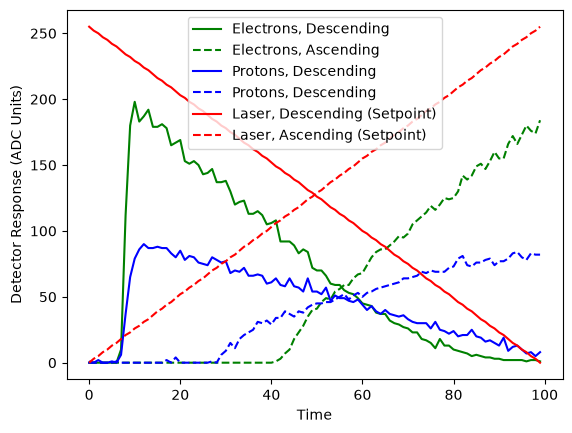

In [18]:
pulse_descent = np.round(np.linspace(1, 0, 100)*255)
pulse_ascent = np.round(np.linspace(0, 1, 100)*255)
#pulse_spiky = np.uint8(np.tile([0,0,0,0,0,0,0,0,0,0,255,255,255,255,255,255,255,255,255,255], 5))

uid_descent, = RE(one_pulse(pulse_descent))
uid_ascent, = RE(one_pulse(pulse_ascent))

def get_traces(uid, tiled_client=tiled_client):
    """ Extract relevant traces from a single-pulse run, identified by uid """
    elecs = tiled_client[uid, 'primary']['electron_pva-trace-array'].read().flatten()
    prots = tiled_client[uid, 'primary']['proton_pva-trace-array'].read().flatten()
    pulse = tiled_client[uid, 'primary']['laser_powers'].read().flatten()
    return elecs, prots, pulse
    
elecs1, prots1, pulse1 = get_traces(uid_descent)
elecs2, prots2, pulse2 = get_traces(uid_ascent)
#elecs3, prots3, pulse3 = realpulse(pulse_spiky)

plt.plot(elecs1, label="Electrons, Descending", c='g')
plt.plot(elecs2, '--', label="Electrons, Ascending", c='g')
#plt.plot(elecs3, '-.', label="Electrons, Spiky", c='g')
plt.plot(prots1, label="Protons, Descending", c='b')
plt.plot(prots2, '--', label="Protons, Descending", c='b')
#plt.plot(prots3, '-.', label="Protons, Spiky", c='b')
plt.plot(pulse1, label="Laser, Descending (Setpoint)", c='r')
plt.plot(pulse2, '--', label="Laser, Ascending (Setpoint)", c='r')
#plt.plot(pulse3, '-.', label="Laser, Spiky (Setpoint)", c='r')
plt.ylabel("Detector Response (ADC Units)")
plt.xlabel("Time")
plt.legend()

## Explore: How would we take multiple datapoints

In [19]:
uid, = RE(count([electron_pva.trace, proton_pva.trace], num=20))

In [20]:
list(tiled_client[uid, 'primary'])

['seq_num',
 'time',
 'electron_pva-trace-array',
 'electron_pva-trace-uniqueId',
 'electron_pva-trace-timeStamp',
 'proton_pva-trace-array',
 'proton_pva-trace-uniqueId',
 'proton_pva-trace-timeStamp',
 'ts_electron_pva-trace-array',
 'ts_electron_pva-trace-uniqueId',
 'ts_electron_pva-trace-timeStamp',
 'ts_proton_pva-trace-array',
 'ts_proton_pva-trace-uniqueId',
 'ts_proton_pva-trace-timeStamp']

In [21]:
tiled_client[uid, 'primary']['electron_pva-trace-uniqueId'].read()

array([9386884, 9386887, 9386888, 9386889, 9386890, 9386891, 9386893,
       9386893, 9386894, 9386897, 9386898, 9386899, 9386900, 9386902,
       9386907, 9386908, 9386909, 9386910, 9386912, 9386913])

In [22]:
tiled_client[uid, 'primary']['proton_pva-trace-uniqueId'].read()

array([9386884, 9386887, 9386888, 9386889, 9386890, 9386891, 9386892,
       9386893, 9386894, 9386896, 9386897, 9386899, 9386900, 9386905,
       9386906, 9386908, 9386909, 9386910, 9386911, 9386913])

In [23]:
tiled_client[uid, 'primary']['electron_pva-trace-array'].read()[1]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   1,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   1,   0,   3,   4,   7,  14,  20,  26,  27,  33,  40,
        48,  48,  53,  57,  57,  58,  66,  70,  66,  72,  75,  76,  78,
        87,  91,  89,  94,  98,  98,  98, 104, 107, 104, 114, 118, 121,
       119, 128, 131, 131, 137, 141, 147, 145, 148, 152, 155, 153, 157,
       161, 165, 168, 172, 179, 174, 177, 181, 183], dtype=uint16)

## Explore: Create plan to Set Laser Powers and Return Traces (with Multiple Reps)

In [29]:
def one_pulse2(pulse, reps=1, md=None):
    # Data validity checks
    assert(isinstance(pulse, np.ndarray))
    assert(np.ndim(pulse) == 1)
    assert(len(pulse) == 100)
    assert(np.max(pulse) <= 255)
    assert(np.min(pulse) >= 0)
    if (np.count_nonzero(pulse - pulse.round() > 0)):
        raise Exception("Pulse array contains fractional values (should be only integers, from 0 to 255).")

    # Data type conversion to uint8
    pulse_uint8 = np.uint8(pulse)


    _md = {
        "plan_name": "one_pulse2",
        "purpose": "Set one laser power pulse and acquire multiple consecutive electron/proton traces.",
        "reps": reps,
    }

    if md is not None:
        _md.update(md)

    yield from bps.open_run(md=_md)
    
    yield from bps.mv(
        laser.powers, pulse_uint8,
    )

    yield from bps.trigger_and_read([
        laser.powers,
    ], name="settings")

    for i in range(reps):
        yield from bps.trigger_and_read([
            electron_pva.trace,
            proton_pva.trace,
        ], name="primary")

    yield from bps.close_run()

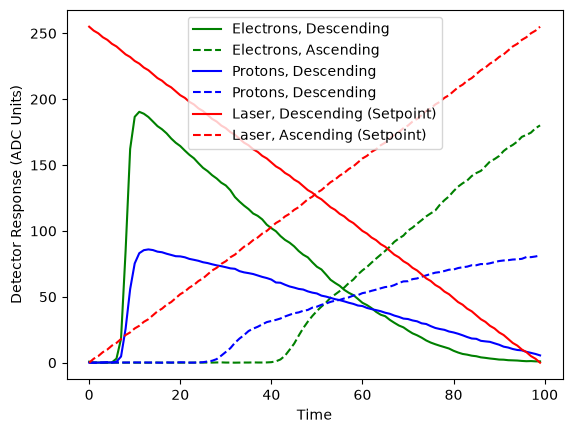

In [30]:
pulse_descent = np.round(np.linspace(1, 0, 100)*255)
pulse_ascent = np.round(np.linspace(0, 1, 100)*255)
#pulse_spiky = np.uint8(np.tile([0,0,0,0,0,0,0,0,0,0,255,255,255,255,255,255,255,255,255,255], 5))

reps = 50

uid_descent, = RE(one_pulse2(pulse_descent, reps=reps))
uid_ascent, = RE(one_pulse2(pulse_ascent, reps=reps))


def get_traces(uid, tiled_client=tiled_client):
    """ Extract relevant traces from a single-pulse run, identified by uid """
    elecs = tiled_client[uid, 'primary']['electron_pva-trace-array'].read().mean(axis=0)
    prots = tiled_client[uid, 'primary']['proton_pva-trace-array'].read().mean(axis=0)
    pulse = tiled_client[uid, 'settings']['laser_powers'].read().flatten()
    return elecs, prots, pulse
    
elecs1, prots1, pulse1 = get_traces(uid_descent)
elecs2, prots2, pulse2 = get_traces(uid_ascent)
#elecs3, prots3, pulse3 = realpulse(pulse_spiky)

plt.plot(elecs1, label="Electrons, Descending", c='g')
plt.plot(elecs2, '--', label="Electrons, Ascending", c='g')
#plt.plot(elecs3, '-.', label="Electrons, Spiky", c='g')
plt.plot(prots1, label="Protons, Descending", c='b')
plt.plot(prots2, '--', label="Protons, Descending", c='b')
#plt.plot(prots3, '-.', label="Protons, Spiky", c='b')
plt.plot(pulse1, label="Laser, Descending (Setpoint)", c='r')
plt.plot(pulse2, '--', label="Laser, Ascending (Setpoint)", c='r')
#plt.plot(pulse3, '-.', label="Laser, Spiky (Setpoint)", c='r')
plt.ylabel("Detector Response (ADC Units)")
plt.xlabel("Time")
plt.legend()

## Next up: Try this as a ["List Scan"](https://nsls-ii.github.io/bluesky/generated/bluesky.plans.list_scan.html)

In [38]:
uid_descent

'0589c64e-d130-45bb-8a19-65d670b69c53'

In [39]:
list(tiled_client[uid_descent].keys())

['primary', 'settings']

In [40]:
tiled_client[uid_descent, 'settings']

<BlueskyEventStream {'time', 'laser_powers'} stream_name='settings'>

### List scan with single rep per stop

In [70]:
def condition_pulse(pulse):
    """ Check pulse array readiness for writing Sidekick Model 3 LilLaser, and cast to uint8 """

    # Data validity checks
    assert(isinstance(pulse, np.ndarray))
    assert(np.ndim(pulse) == 1)
    assert(len(pulse) == 100)
    assert(np.max(pulse) <= 255)
    assert(np.min(pulse) >= 0)
    if (np.count_nonzero(pulse - pulse.round() > 0)):
        raise Exception("Pulse array contains fractional values (should be only integers, from 0 to 255).")

    # Data type conversion to uint8
    pulse_uint8 = np.uint8(pulse)

    return pulse_uint8

In [71]:
pulse_descent = condition_pulse(np.round(np.linspace(1, 0, 100)*255))
pulse_ascent = condition_pulse(np.round(np.linspace(0, 1, 100)*255))
pulse_spiky = condition_pulse(np.tile([0,0,0,0,0,0,0,0,0,0,255,255,255,255,255,255,255,255,255,255], 5))
pulse_zero = condition_pulse(np.ones(100)*0)
pulse_255 = condition_pulse(np.ones(100)*255)
pulse_125 = condition_pulse(np.ones(100)*125)

# Action list
pulse_list = [
    pulse_descent,
    pulse_zero,
    pulse_ascent,
    pulse_zero,
    pulse_spiky,
    pulse_zero,
    pulse_255,
]

In [72]:
detectors = [electron_pva.trace, proton_pva.trace]
motor = laser.powers
motor_points = pulse_list
md = {"user_note" : "Testing a list scan on Sidekick Model 3"}

In [89]:
uid, = RE(list_scan(detectors, motor, motor_points, md=md, per_step=array_one_nd_step))

In [104]:
tiled_client[uid, 'primary']

<BlueskyEventStream {'electron_pva-trace-uniqueId', 'proton_pva-trace-uniqueId', 'proton_pva-trace-timeStamp', 'electron_pva-trace-timeStamp', 'laser_powers', 'proton_pva-trace-array', 'electron_pva-trace-array', 'time'} stream_name='primary'>

In [101]:
tiled_client[uid, 'primary']['laser_powers']

<ArrayClient shape=(7, 100) chunks=((7,), (100,)) dtype=int32>

In [105]:
tiled_client[uid, 'primary']['laser_powers'][3]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=uint16)

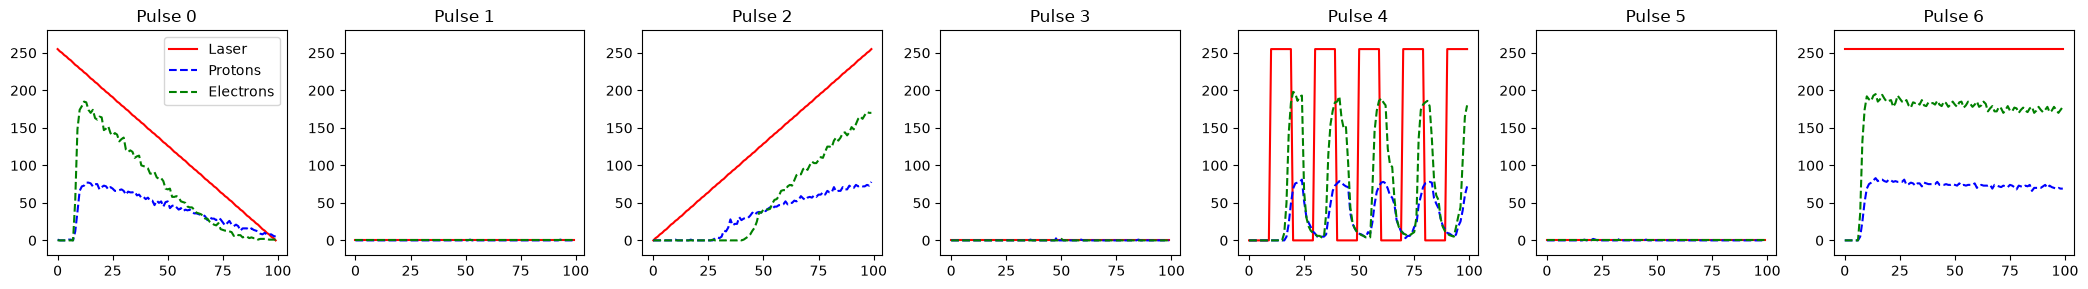

In [115]:
# Written by ChatGPT with help from Scott Feister on 2026-06-25.

import matplotlib.pyplot as plt

primary = tiled_client[uid, "primary"]
pulse = primary["laser_powers"].read()
proton = primary["proton_pva-trace-array"].read()
electron = primary["electron_pva-trace-array"].read()

fig, axes = plt.subplots(1, len(pulse), figsize=(3 * len(pulse), 3))

for i, ax in enumerate(axes):
    ax.plot(pulse[i], label="Laser", c='r')
    ax.plot(proton[i], "--", label="Protons", c='b')
    ax.plot(electron[i], "--", label="Electrons", c='g')
    ax.set_ylim([-20, 280])
    ax.set_title(f"Pulse {i}")

axes[0].legend()
plt.tight_layout()
plt.show()

In [117]:
"""
Export one specific kind of run to from Tiled to HDF5.

Created by ChatGPT with help from Scott Feister on 2026-06-25.
"""

from pathlib import Path

import h5py
import numpy as np


def export_run_to_hdf5_custom(tiled_client, uid, filename=None):
    if filename is None:
        filename = f"run_{uid}.h5"

    filename = Path(filename)
    filename.parent.mkdir(parents=True, exist_ok=True)

    primary = tiled_client[uid, "primary"]

    with h5py.File(filename, "w") as f:
        f.attrs["uid"] = uid

        g = f.create_group("primary")

        g.create_dataset("laser_powers", data=np.asarray(primary["laser_powers"]))
        g.create_dataset("electron_trace", data=np.asarray(primary["electron_pva-trace-array"]))
        g.create_dataset("proton_trace", data=np.asarray(primary["proton_pva-trace-array"]))

    return filename

In [118]:
export_run_to_hdf5_custom(tiled_client, uid, f"outputs/run_{uid}.h5")

WindowsPath('outputs/run_41c59426-aedb-456c-8fbe-02d19dd17311.h5')

In [121]:
from export_helpers import export_run_to_hdf5 # local import

In [120]:
export_run_to_hdf5(tiled_client, uid, f"outputs/run_{uid}-2.h5")

WindowsPath('outputs/run_41c59426-aedb-456c-8fbe-02d19dd17311-2.h5')

In [127]:
from tiled_browsers import summarize_runs # local import

In [125]:
df = summarize_runs(tiled_client)
df.info()

Label(value='⟳ Retrying…')

Label(value='⟳ Retrying…')

Label(value='⟳ Retrying…')

Label(value='⟳ Retrying…')

Label(value='⟳ Retrying…')

Label(value='⟳ Retrying…')

Label(value='⟳ Retrying…')

Label(value='⟳ Retrying…')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   time                15 non-null     object 
 1   scan_id             15 non-null     int64  
 2   plan_name           15 non-null     object 
 3   ok                  15 non-null     bool   
 4   exit_status         15 non-null     object 
 5   duration_s          15 non-null     float64
 6   uid_short           15 non-null     object 
 7   uid                 15 non-null     object 
 8   project             0 non-null      object 
 9   system              0 non-null      object 
 10  purpose             2 non-null      object 
 11  sample              0 non-null      object 
 12  operator            0 non-null      object 
 13  notes               0 non-null      object 
 14  streams             15 non-null     object 
 15  num_streams         15 non-null     int64  
 16  primary_fi

In [126]:
df["primary_fields"]

0     seq_num, time, electron_pva-trace-array, elect...
1     seq_num, time, electron_pva-trace-array, elect...
2     seq_num, time, electron_pva-trace-array, elect...
3     seq_num, time, electron_pva-trace-array, elect...
4     seq_num, time, electron_pva-trace-array, elect...
5                                                      
6                                                      
7     seq_num, time, electron_pva-trace-array, elect...
8     seq_num, time, electron_pva-trace-array, elect...
9     seq_num, time, electron_pva-trace-array, elect...
10    seq_num, time, electron_pva-trace-array, elect...
11    seq_num, time, electron_pva-trace-array, elect...
12    seq_num, time, laser_powers, electron_pva-trac...
13    seq_num, time, laser_powers, electron_pva-trac...
14    seq_num, time, laser_powers, electron_pva-trac...
Name: primary_fields, dtype: object

## Let's try the same scan but build in some averaging etc

### Set up and Take the Run

In [137]:
import bluesky.plan_stubs as bps
from bluesky.plan_stubs import trigger_and_read
from ophyd.sim import SynSignal

def array_one_nd_step_with_reps(reps=1):
    """
    Return a per_step function for list_scan with array-valued positions.

    The returned function has the standard Bluesky per_step signature:

        per_step(detectors, step, pos_cache)

    Adds:
        scan_step : scan position index, starting at 0
        scan_rep  : repeated reading index at that position, starting at 0

    Written by ChatGPT with help from Scott Feister on 2026-06-26.
    """

    if reps < 1:
        raise ValueError("reps must be >= 1")

    state = {"step": -1, "rep": 0}

    scan_step = SynSignal(lambda: state["step"], name="scan_step")
    scan_rep = SynSignal(lambda: state["rep"], name="scan_rep")

    def per_step(detectors, step, pos_cache):
        motors = list(step.keys())

        state["step"] += 1

        # Always move; do not compare NumPy arrays against cached positions.
        yield from bps.checkpoint()
        for motor, pos in step.items():
            yield from bps.mv(motor, pos)
            pos_cache[motor] = pos

        readables = list(detectors) + motors + [scan_step, scan_rep]

        for rep in range(reps):
            state["rep"] = rep
            yield from trigger_and_read(readables)

    return per_step

In [139]:
detectors = [electron_pva.trace, proton_pva.trace]
motor = laser.powers
motor_points = pulse_list
md = {"user_note" : "Testing a list scan, with repetitions at each step, on Sidekick Model 3"}
uid, = RE(list_scan(detectors, motor, motor_points, md=md, per_step=array_one_nd_step_with_reps(reps=50)))

### Analyze the run results

In [152]:
# Written by ChatGPT with help from Scott Feister on 2026-06-25.

import matplotlib.pyplot as plt

primary = tiled_client[uid, "primary"]

In [153]:
primary

<BlueskyEventStream {'electron_pva-trace-uniqueId', 'proton_pva-trace-uniqueId', 'proton_pva-trace-timeStamp', 'scan_rep', 'electron_pva-trace-timeStamp', 'laser_powers', 'proton_pva-trace-array', 'scan_step', 'electron_pva-trace-array', 'time'} stream_name='primary'>

In [154]:
import numpy as np

def average_traces_by_scan_step(primary):
    """
    Average repeated electron/proton traces at each scan_step.

    Assumes the run contains:
        scan_step
        scan_rep
        laser_powers
        electron_pva-trace-array
        proton_pva-trace-array

    Also assumes every scan_step has the same number of scan_rep readings.

    Written by ChatGPT with help from Scott Feister on 2026-06-26.
    """

    scan_step = np.asarray(primary["scan_step"])
    scan_rep = np.asarray(primary["scan_rep"])

    order = np.lexsort((scan_rep, scan_step))

    scan_step = scan_step[order]
    scan_rep = scan_rep[order]

    steps = np.unique(scan_step)
    reps = np.unique(scan_rep)

    n_steps = len(steps)
    n_reps = len(reps)

    def sorted_array(name):
        return np.asarray(primary[name])[order]

    def by_step_and_rep(name):
        return sorted_array(name).reshape(n_steps, n_reps, -1)

    electron = by_step_and_rep("electron_pva-trace-array")
    proton = by_step_and_rep("proton_pva-trace-array")
    laser_powers = by_step_and_rep("laser_powers")[:, 0, :]

    return {
        "scan_step": steps,
        "scan_rep": reps,
        "laser_powers": laser_powers,
        "electron_mean": electron.mean(axis=1),
        "electron_std": electron.std(axis=1),
        "proton_mean": proton.mean(axis=1),
        "proton_std": proton.std(axis=1),
    }

In [158]:
results = average_traces_by_scan_step(primary)

pulse = results["laser_powers"]
proton = results["proton_mean"]
proton_std = results["proton_std"]
electron = results["electron_mean"]
electron_std = results["electron_std"]

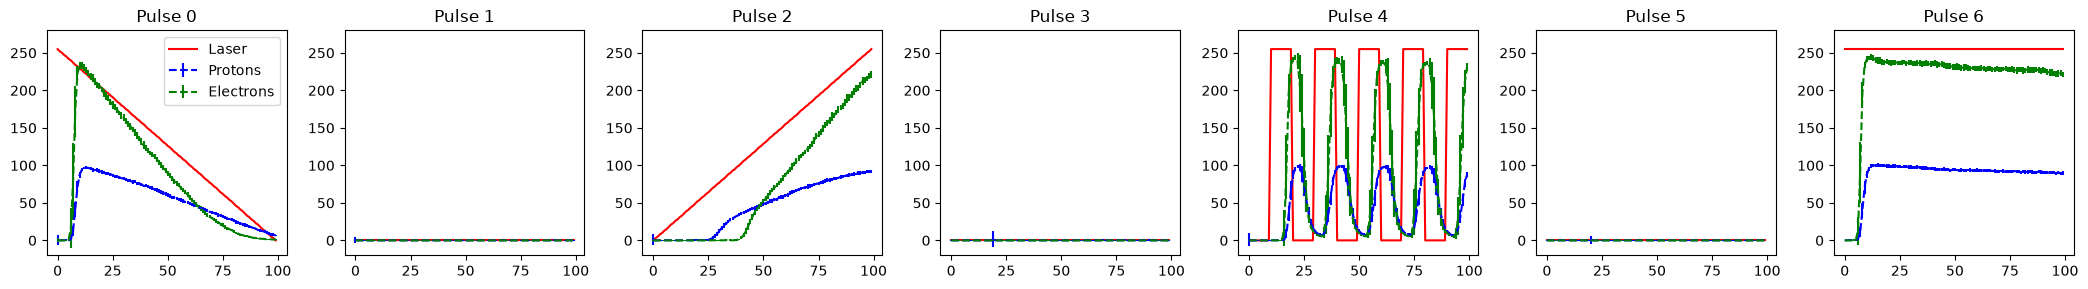

In [164]:
fig, axes = plt.subplots(1, len(pulse), figsize=(3 * len(pulse), 3))

tvals = np.arange(100) # x axis

for i, ax in enumerate(axes):
    ax.plot(tvals, pulse[i], label="Laser", c='r')
    ax.errorbar(tvals, proton[i], yerr=proton_std[i], fmt="--", label="Protons", c='b')
    ax.errorbar(tvals, electron[i], yerr=electron_std[i], fmt="--", label="Electrons", c='g')
    ax.set_ylim([-20, 280])
    ax.set_title(f"Pulse {i}")

axes[0].legend()
plt.tight_layout()
plt.show()

### Export a File

In [180]:
"""
Export one specific kind of run to from Tiled to HDF5.

Created by ChatGPT with help from Scott Feister on 2026-06-25.
"""

from pathlib import Path

import h5py
import numpy as np


def export_run_to_hdf5_custom2(tiled_client, uid, filename=None):
    if filename is None:
        filename = f"run_{uid}.h5"

    filename = Path(filename)
    filename.parent.mkdir(parents=True, exist_ok=True)

    primary = tiled_client[uid, "primary"]

    with h5py.File(filename, "w") as f:
        f.attrs["uid"] = uid

        g = f.create_group("primary")

        g.create_dataset("scan_step", data=np.asarray(primary["scan_step"]))
        g.create_dataset("scan_rep", data=np.asarray(primary["scan_rep"]))
        g.create_dataset("laser_powers", data=np.asarray(primary["laser_powers"]))
        g.create_dataset("electron_trace", data=np.asarray(primary["electron_pva-trace-array"]))
        g.create_dataset("electron_shot_num", data=np.asarray(primary["electron_pva-trace-uniqueId"]))
        g.create_dataset("proton_trace", data=np.asarray(primary["proton_pva-trace-array"]))
        g.create_dataset("proton_shot_num", data=np.asarray(primary["proton_pva-trace-uniqueId"]))

    return filename

In [181]:
"""
Export one specific kind of run (rep-rated etrace/ptrace list) to from Tiled to HDF5.

Created by ChatGPT with help from Scott Feister on 2026-06-25.
"""

from pathlib import Path

import h5py
import numpy as np

def export_run_to_hdf5_custom(tiled_client, uid, filename=None):
    if filename is None:
        filename = f"run_{uid}.h5"

    filename = Path(filename)
    filename.parent.mkdir(parents=True, exist_ok=True)

    primary = tiled_client[uid, "primary"]

    with h5py.File(filename, "w") as f:
        f.attrs["uid"] = uid

        g = f.create_group("primary")

        g.create_dataset("laser_powers", data=np.asarray(primary["laser_powers"]))
        g.create_dataset("electron_trace", data=np.asarray(primary["electron_pva-trace-array"]))
        g.create_dataset("proton_trace", data=np.asarray(primary["proton_pva-trace-array"]))

    return filename

In [182]:
primary

<BlueskyEventStream {'electron_pva-trace-uniqueId', 'proton_pva-trace-uniqueId', 'proton_pva-trace-timeStamp', 'scan_rep', 'electron_pva-trace-timeStamp', 'laser_powers', 'proton_pva-trace-array', 'scan_step', 'electron_pva-trace-array', 'time'} stream_name='primary'>

In [183]:
export_run_to_hdf5_custom2(tiled_client, uid, f"outputs/run_{uid}.h5")

WindowsPath('outputs/run_6e9d0cca-d40e-4389-bf92-5430b57d3000.h5')

## 100 random traces with 5 reps on each?

In [212]:
npulses = 50
reps = 5

pulse_list = [condition_pulse(np.round(np.random.rand(100)*255)) for i in range(2000)]
pulse_list[0].shape

(100,)

In [ ]:
%%time

detectors = [electron_pva.trace, proton_pva.trace]
motor = laser.powers
motor_points = pulse_list
md = {"user_note" : "A bunch of random traces, list scan on Sidekick Model 3"}
uid, = RE(list_scan(detectors, motor, motor_points, md=md, per_step=array_one_nd_step_with_reps(reps=reps)))